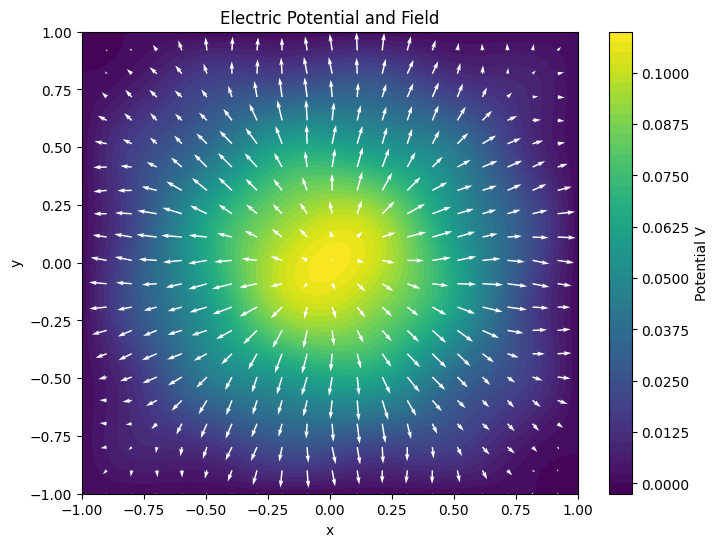

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
N = 100
x = np.linspace(-1,1,N)
y = np.linspace(-1,1,N)
dx = x[1] - x[0]

X, Y = np.meshgrid(x,y)

# Charge density
rho = np.exp(-5*(X**2 + Y**2)) + 0.5*np.sin(3*np.pi*X)*np.sin(3*np.pi*Y)

# Initialize potential
V = np.zeros_like(rho)

# Finite difference (Jacobi method)
for _ in range(5000):
    V_new = V.copy()
    V_new[1:-1,1:-1] = 0.25 * (
        V[2:,1:-1] + V[:-2,1:-1] +
        V[1:-1,2:] + V[1:-1,:-2] +
        dx**2 * rho[1:-1,1:-1]
    )
    V = V_new

# Electric field
Ey, Ex = np.gradient(-V, dx)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(X, Y, V, levels=50)
plt.colorbar(label='Potential V')

plt.quiver(X[::5,::5], Y[::5,::5], Ex[::5,::5], Ey[::5,::5], color='white')
plt.title("Electric Potential and Field")
plt.xlabel("x")
plt.ylabel("y")

plt.show()